In [121]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [5]:
pd.set_option('display.max_columns', None)
df = pd.read_excel('Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [9]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [10]:
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Reason",
    "Churn Category",
    "Churn Value",
    "Churn Score",
    "CLTV"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [11]:
df = df.rename(columns={"Churn Label": "Churn"})

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Comverting Total charges datatype from obj to float

In [16]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")


Countplot showing distribution of churn

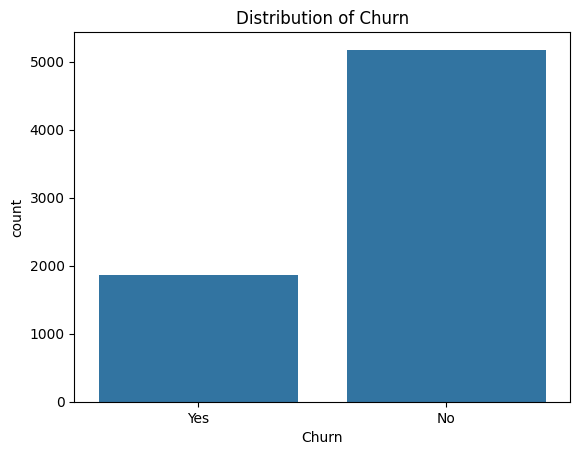

In [18]:
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.show() 


Countplot to show churn based on contract type

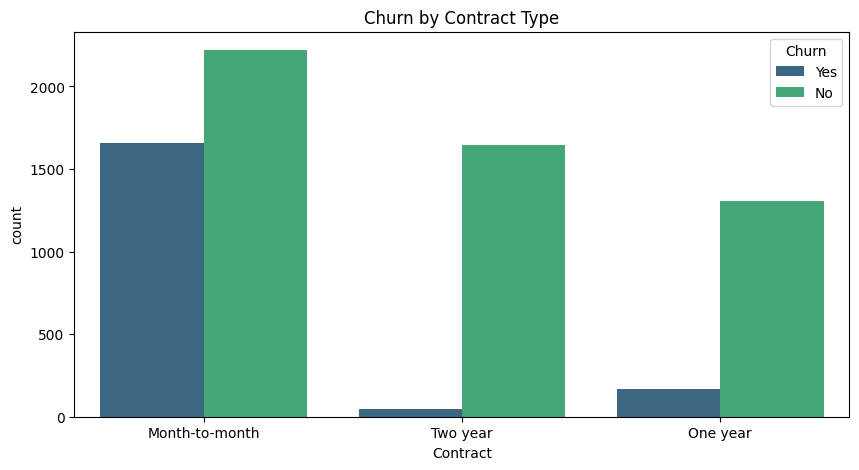

In [19]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn by Contract Type')
plt.show()

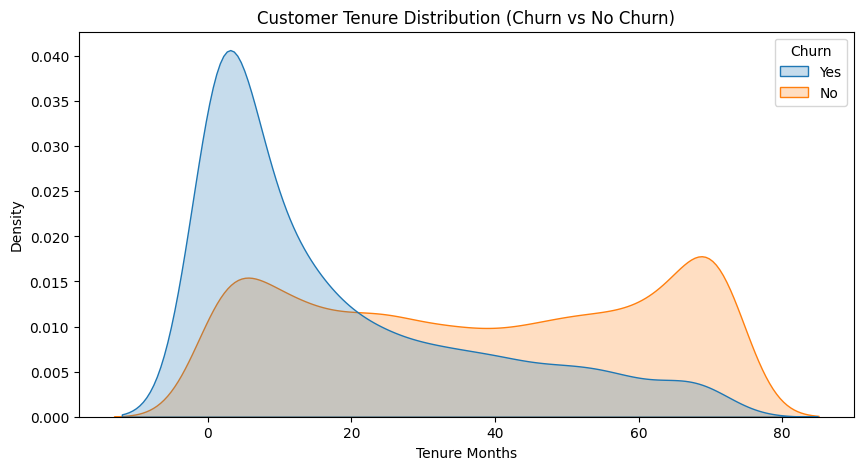

In [20]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Tenure Months', hue='Churn', fill=True, common_norm=False)
plt.title('Customer Tenure Distribution (Churn vs No Churn)')
plt.show()

It is clearly visible that customers who are subscribed on monthly basis tend to churn more as compared to customers who hold 1yr or 2yrs contract.

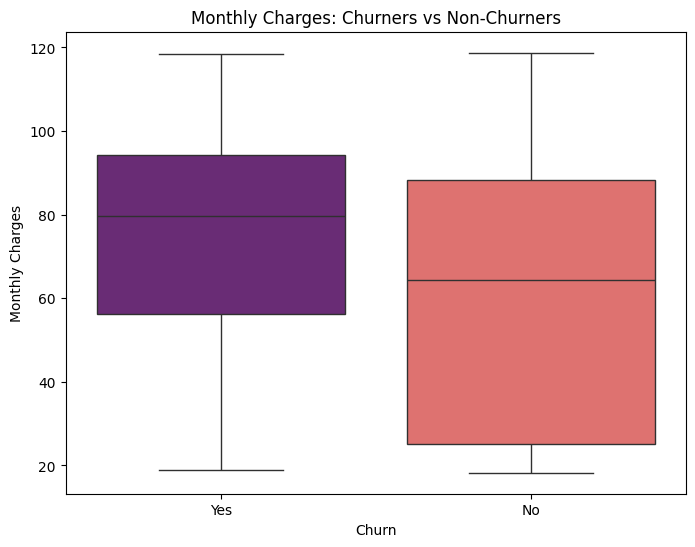

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Churn', y='Monthly Charges', palette='magma')
plt.title('Monthly Charges: Churners vs Non-Churners')
plt.show()

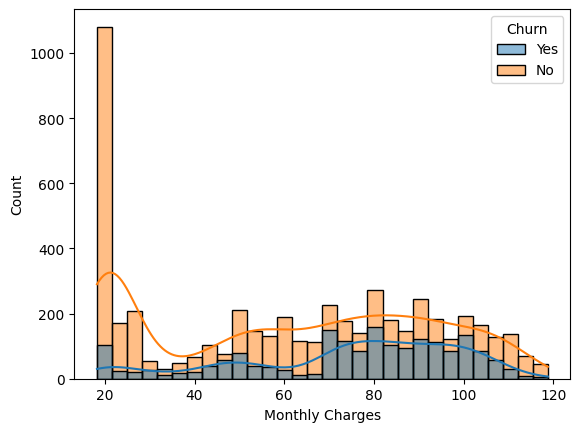

In [35]:
sns.histplot(data=df, x="Monthly Charges", hue="Churn", bins=30, kde=True)
plt.show()

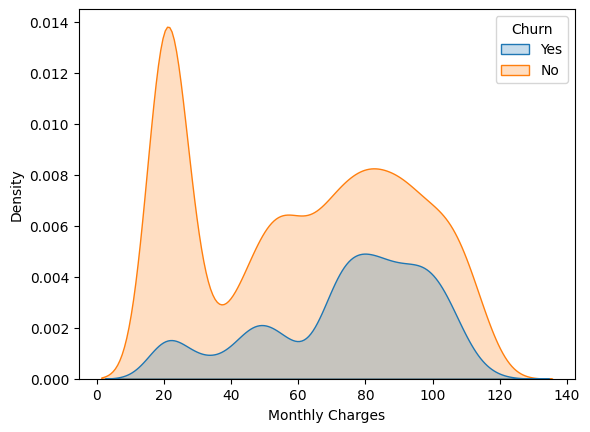

In [27]:
sns.kdeplot(data=df, x="Monthly Charges", hue="Churn", fill=True)
plt.show()

Customers with high monthly chares tend to churn more

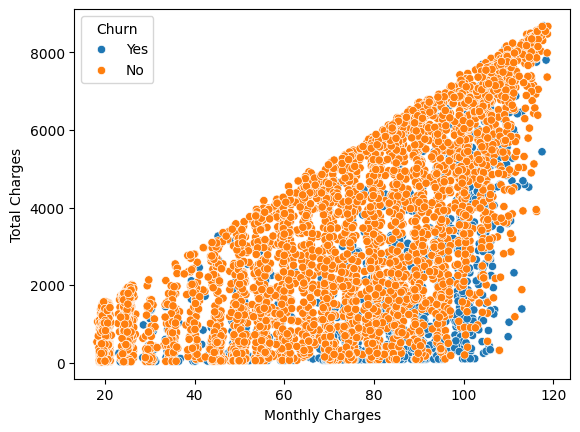

In [28]:
sns.scatterplot(
    data=df,
    x="Monthly Charges",
    y="Total Charges",
    hue="Churn"
)
plt.show()

Feature engineering

Creating a high risk customer feature where the contract is month-to-month and monthly charges exceed 70.

In [38]:
df["High Risk"] = ((df["Contract"] == "Month-to-month") & 
                  (df["Monthly Charges"] > 70)).astype(int)

In [39]:
df['High Risk'].value_counts()


High Risk
0    4946
1    2097
Name: count, dtype: int64

In [45]:
df["Tenure Group"] = pd.cut(df["Tenure Months"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=["0-1yr", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5-6yr"])

In [46]:
df['Tenure Group'].value_counts()

Tenure Group
0-1yr    2175
5-6yr    1407
1-2yr    1024
2-3yr     832
4-5yr     832
3-4yr     762
Name: count, dtype: int64

In [49]:
df['High Risk'].value_counts()

High Risk
0    4946
1    2097
Name: count, dtype: int64

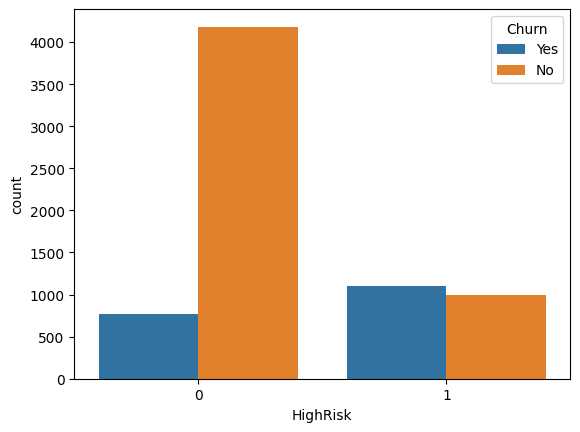

In [53]:
sns.countplot(x="HighRisk", hue="Churn", data=df)
plt.show()

In [54]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,HighRisk,High Risk,Tenure Group
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,0,0-1yr
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,1,0-1yr
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,1,0-1yr
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,1,2-3yr
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,1,4-5yr


In [55]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [56]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn,HighRisk,High Risk,Tenure Group
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0,0,0-1yr
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,1,0-1yr
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,1,1,0-1yr
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,1,1,2-3yr
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,1,1,4-5yr


In [57]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.shape

(7043, 38)

In [58]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
y_pred = model.predict(X_test)

In [64]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7881885292447472
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1262
           1       0.66      0.51      0.58       499

    accuracy                           0.79      1761
   macro avg       0.74      0.71      0.72      1761
weighted avg       0.78      0.79      0.78      1761



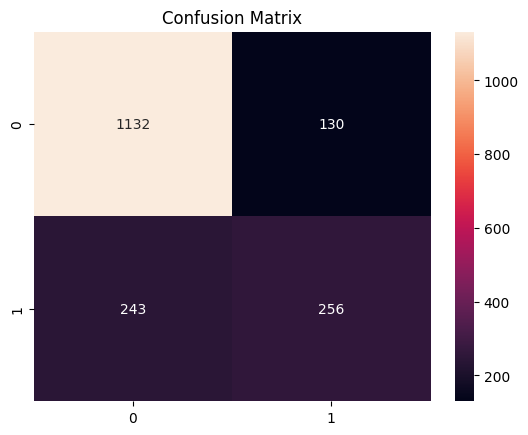

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [81]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
import xgboost as xgb

In [83]:
from xgboost import XGBClassifier

model = XGBClassifier(scale_pos_weight=3)

In [85]:
neg = sum(y_train == 0)
pos = sum(y_train == 1)

scale_pos_weight = neg / pos

print(scale_pos_weight)

2.8554744525547444


In [86]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [87]:
y_prob = model.predict_proba(X_test)[:,1]

In [88]:
threshold = 0.3 

y_pred = (y_prob > threshold).astype(int)

In [89]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7018739352640545
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1262
           1       0.49      0.87      0.62       499

    accuracy                           0.70      1761
   macro avg       0.71      0.75      0.69      1761
weighted avg       0.80      0.70      0.72      1761



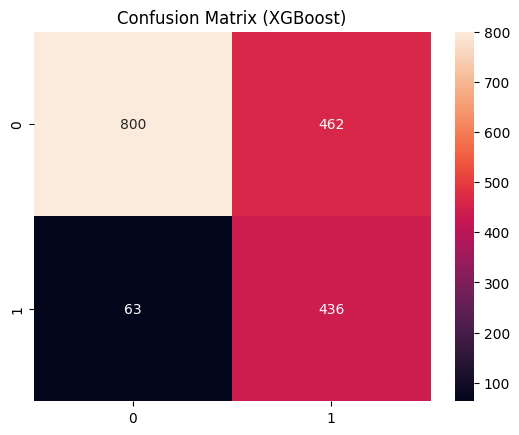

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

In [91]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

HighRisk                           0.312496
Contract_Two year                  0.136187
Internet Service_No                0.133112
Dependents_Yes                     0.052707
Contract_One year                  0.045479
Streaming Movies_Yes               0.036430
Internet Service_Fiber optic       0.036213
Tenure Months                      0.024201
Payment Method_Electronic check    0.022688
Online Security_Yes                0.014722
dtype: float32

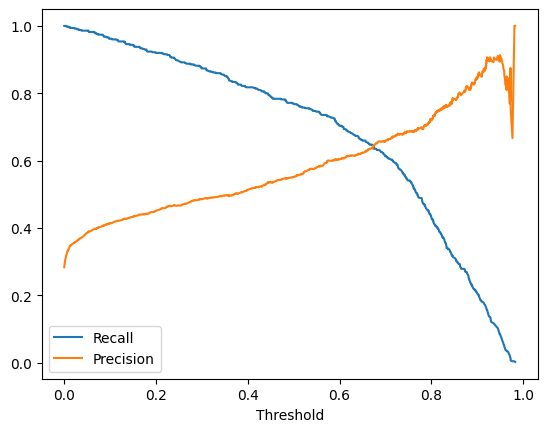

In [92]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)

import matplotlib.pyplot as plt

plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.legend()
plt.xlabel("Threshold")
plt.show()

In [93]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_prob > t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1262
           1       0.49      0.87      0.62       499

    accuracy                           0.70      1761
   macro avg       0.71      0.75      0.69      1761
weighted avg       0.80      0.70      0.72      1761


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1262
           1       0.51      0.82      0.63       499

    accuracy                           0.73      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.79      0.73      0.74      1761


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1262
           1       0.55      0.77      0.64       499

    accuracy                           0.76      1761
   macro avg       0.72      0.76      0.73      1761
weighted avg       0.79   

In [101]:
threshold = 0.4

y_pred = (y_prob > threshold).astype(int)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.69      0.79      1262
           1       0.51      0.82      0.63       499

    accuracy                           0.73      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.79      0.73      0.74      1761



In [107]:
import joblib

joblib.dump(X.columns.tolist(), "models/features.pkl")

['models/features.pkl']

In [108]:
joblib.dump(model, "models/xgb_model.pkl")

['models/xgb_model.pkl']